# 03 — Prédiction de l'attrition des collaborateurs

## Objectif

Cette étape vise à construire un modèle permettant d'estimer la probabilité
d'attrition d'un collaborateur à partir de ses caractéristiques individuelles
et professionnelles.

Contrairement à l'analyse statistique univariée réalisée précédemment,
l'objectif est ici d'étudier simultanément plusieurs variables afin :

- d'estimer une probabilité individuelle d'attrition ;
- d'évaluer la capacité prédictive du modèle ;
- d'identifier les caractéristiques associées au risque d'attrition
  toutes choses égales par ailleurs ;
- de produire un scoring exploitable dans Power BI.

Une régression logistique est retenue comme modèle principal en raison de
son interprétabilité et de son adéquation avec une variable cible binaire.

La variable cible est `Attrition`, codée :

- `0` : collaborateur resté dans l'entreprise ;
- `1` : collaborateur ayant quitté l'entreprise.

Les résultats du modèle seront interprétés comme des associations
prédictives et non comme des relations causales.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

In [28]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus
server = r"(localdb)\ProjectModels"
database = "Hr_analytics"

connection_string = quote_plus(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={connection_string}")
query = """
SELECT  *
FROM PROCESSED.employees;
"""

df = pd.read_sql(query, engine)


c:\Users\user\anaconda3\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.4025.3'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


In [29]:
df_model = df.copy()

df_model["AttritionFlag"] = df_model["Attrition"].map({"No": 0, "Yes": 1})

df_model["AttritionFlag"].value_counts()


AttritionFlag
0    1233
1     237
Name: count, dtype: int64

In [30]:
target = "AttritionFlag"

columns_to_exclude = [
    "Attrition",
    "AttritionFlag",
    "EmployeeNumber",
]

X = df_model.drop(columns=columns_to_exclude, errors="ignore")

y = df_model[target]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

display(X.head())


Dimensions de X : (1470, 30)
Dimensions de y : (1470,)


,Age,Gender,MaritalStatus,Department,JobRole,JobLevel,BusinessTravel,Education,EducationField,TotalWorkingYears,NumCompaniesWorked,TrainingTimesLastYear,MonthlyIncome,PercentSalaryHike,StockOptionLevel,HourlyRate,DailyRate,MonthlyRate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,DistanceFromHome,OverTime,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Female,Single,Sales,Sales Executive,2,Travel_Rarely,2,Life Sciences,8,8,0,5993,11,0,94,1102,19479,2,4,1,1,3,3,1,Yes,6,4,0,5
1,49,Male,Married,Research & Development,Research Scientist,2,Travel_Frequently,1,Life Sciences,10,1,3,5130,23,1,61,279,24907,3,2,4,3,2,4,8,No,10,7,1,7
2,37,Male,Single,Research & Development,Laboratory Technician,1,Travel_Rarely,2,Other,7,6,3,2090,15,0,92,1373,2396,4,3,2,3,2,3,2,Yes,0,0,0,0
3,33,Female,Married,Research & Development,Research Scientist,1,Travel_Frequently,4,Life Sciences,8,1,3,2909,11,0,56,1392,23159,4,3,3,3,3,3,3,Yes,8,7,3,0
4,27,Male,Married,Research & Development,Laboratory Technician,1,Travel_Rarely,1,Medical,6,9,3,3468,12,1,40,591,16632,1,2,4,3,3,3,2,No,2,2,2,2


## Sélection initiale des variables

La sélection initiale des prédicteurs s'appuie sur les résultats obtenus dans
le notebook `01_statistical_analysis.ipynb`.

Les analyses univariées ont permis d'identifier les variables présentant une
association statistiquement détectable avec l'attrition après correction du
risque de faux positifs par la méthode de Benjamini-Hochberg.

Les variables numériques ont été étudiées à l'aide du test de Mann-Whitney,
complété par la corrélation rang-bisérielle comme mesure de taille d'effet.

Les variables catégorielles ont été étudiées à l'aide du test du Chi²
d'indépendance et du V de Cramér, complétés par l'analyse des résidus
standardisés, des Odds Ratios et des Risk Ratios.

Les dépendances entre prédicteurs numériques ont ensuite été étudiées à
l'aide des corrélations de Spearman et du Variance Inflation Factor (VIF).

Une forte redondance a notamment été observée entre `JobLevel` et
`MonthlyIncome` (ρ ≈ 0,92), accompagnée de VIF supérieurs à 10.
`JobLevel` a donc été retirée de cette première spécification au profit de
`MonthlyIncome`. Après cette suppression, les VIF des variables conservées
restent inférieurs à 5.

Cette sélection vise à construire un premier modèle multivarié parcimonieux
et interprétable. Elle ne suppose cependant pas qu'une variable non
significative en analyse univariée soit nécessairement dépourvue de valeur
prédictive dans un contexte multivarié.

In [31]:
numeric_features = [
    "Age",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "MonthlyIncome",
    "StockOptionLevel",
    "JobInvolvement",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "DistanceFromHome",
]

categorical_features = [
    "OverTime",
    "JobRole",
    "MaritalStatus",
    "BusinessTravel",
    "EducationField",
    # "Department",
]

selected_features = numeric_features + categorical_features

X = df_model[selected_features].copy()
y = df_model["AttritionFlag"]


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

print("\nAttrition train :", y_train.mean().round(4))

print("Attrition test :", y_test.mean().round(4))


Train : (1176, 16)
Test  : (294, 16)

Attrition train : 0.1616
Attrition test : 0.1599


In [33]:
RANDOM_STATE = 42

In [34]:
NumericalTransformer = Pipeline([
    ("Scaler" , StandardScaler())
])
CategoricalTransformer = Pipeline([
    ( 
        "OneHot" , OneHotEncoder(handle_unknown = 'ignore' , drop = 'first')
    )
])

Preprocessor = ColumnTransformer([
    (
        "Numeric" , NumericalTransformer , numeric_features
    ) ,
    (
        "categorical" , CategoricalTransformer , categorical_features
    )
])


Baseline = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)


Model_pipeline = Pipeline(
    [
        ("Preprocessor", Preprocessor) ,
        ("Model" ,Baseline)
    ]
        )

In [35]:
Model_pipeline.fit(
    X_train , 
    y_train
)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('Numeric',
                                                  Pipeline(steps=[('Scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'TotalWorkingYears',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsWithCurrManager',
                                                   'MonthlyIncome',
                                                   'StockOptionLevel',
                                                   'JobInvolvement',
                                                   'JobSatisfaction',
                                                   'EnvironmentSatisfaction',
                                                   'DistanceFromHome']),
                                                 ('categorical',
                                                  Pipeline(steps=[('OneHot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['OverTime', 'JobRole',
                                                   'MaritalStatus',
                                                   'BusinessTravel',
                                                   'EducationField'])])),
                ('Model', LogisticRegression(max_iter=3000, random_state=42))])

In [36]:
y_predict = Model_pipeline.predict(X_test) 
y_predict_proba = Model_pipeline.predict_proba(X_test)[:,1]

====================== BASELINE REPORTS ======================


BASELINE = LogisticRegression
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
              precision    recall  f1-score   support

           0       0.88      0.98      0.92       247
           1       0.68      0.28      0.39        47

    accuracy                           0.86       294
   macro avg       0.78      0.63      0.66       294
weighted avg       0.85      0.86      0.84       294

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

ROC-AUC : 0.779
PR-AUC  : 0.537


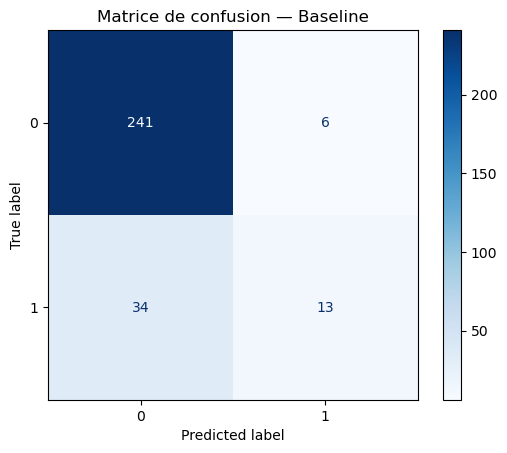

In [37]:
print("=="*31)
print("=="*11 ,"BASELINE REPORTS", "=="*11)
print()
print()
print("BASELINE = LogisticRegression")
print("- " * 31)


print(classification_report(
    y_test ,
    y_predict
))
roc_auc = roc_auc_score(y_test, y_predict_proba)

pr_auc = average_precision_score(y_test, y_predict_proba)
print("- " * 31)
print()


print(f"ROC-AUC : {roc_auc:.3f}")
print(f"PR-AUC  : {pr_auc:.3f}")

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_predict, cmap="Blues")
plt.title("Matrice de confusion — Baseline")
plt.show()

In [38]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_predict_proba)

threshold_results = pd.DataFrame(
    {"Threshold": thresholds, "Precision": precision[:-1], "Recall": recall[:-1]}
)

# threshold_results.query("Recall > 0.5 and Precision > 0.5")

threshold_results["F1"] = (
    2
    * threshold_results["Precision"]
    * threshold_results["Recall"]
    / (threshold_results["Precision"] + threshold_results["Recall"])
)

threshold_results = threshold_results.replace([np.inf, -np.inf], np.nan).dropna()

threshold_results.sort_values("F1", ascending=False).head(10)


,Threshold,Precision,Recall,F1
235,0.244308,0.474576,0.595745,0.528302
234,0.241532,0.466667,0.595745,0.523364
233,0.240880,0.459016,0.595745,0.518519
236,0.246649,0.465517,0.574468,0.514286
232,0.222047,0.451613,0.595745,0.513761
231,0.219797,0.444444,0.595745,0.509091
230,0.211157,0.437500,0.595745,0.504505
226,0.203530,0.426471,0.617021,0.504348
222,0.194652,0.416667,0.638298,0.504202
237,0.253693,0.456140,0.553191,0.500000


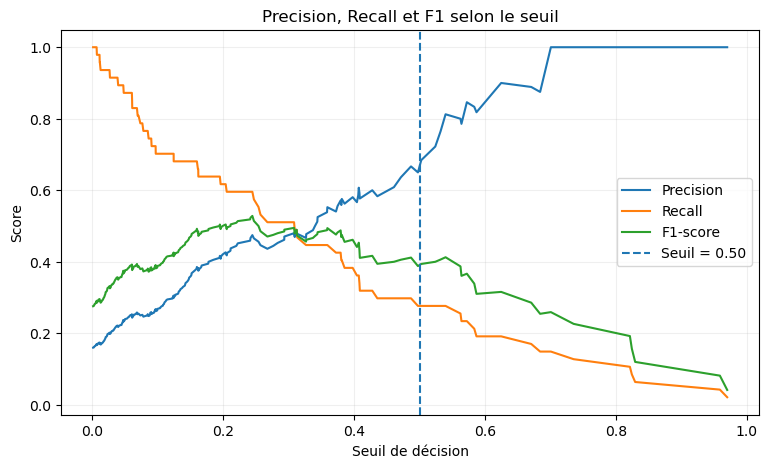

In [39]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["Threshold"], threshold_results["Precision"], label="Precision"
)

plt.plot(threshold_results["Threshold"], threshold_results["Recall"], label="Recall")

plt.plot(threshold_results["Threshold"], threshold_results["F1"], label="F1-score")

plt.axvline(0.50, linestyle="--", label="Seuil = 0.50")

plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Precision, Recall et F1 selon le seuil")
plt.legend()
plt.grid(alpha=0.2)

plt.show()


### Première évaluation de la régression logistique

La régression logistique baseline obtient une ROC-AUC de **0,779** et une
PR-AUC de **0,535**, indiquant une capacité de discrimination intéressante
pour un premier modèle.

Au seuil de décision standard de 0,50, le modèle présente toutefois un
déséquilibre important entre les deux classes. Le rappel de la classe
`Attrition = 1` n'atteint que **0,28**, ce qui signifie qu'une part importante
des départs réels n'est pas détectée.

À l'inverse, la précision de **0,68** indique que les prédictions positives
émises par le modèle sont relativement fiables.

L'accuracy globale de **0,86** doit être interprétée avec prudence en raison
du déséquilibre de la variable cible, seulement environ 16 % des
collaborateurs appartenant à la classe d'attrition.

Ces résultats suggèrent que le modèle possède une capacité de classement
du risque intéressante, mais que le seuil standard de 0,50 n'est pas
nécessairement adapté à l'objectif de détection des collaborateurs à risque.

In [40]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve

# Validation croisée stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Probabilités out-of-fold sur le TRAIN uniquement
y_train_proba_cv = cross_val_predict(
    Model_pipeline, X_train, y_train, cv=cv, method="predict_proba"
)[:, 1]


In [41]:
# Precision / Recall selon le seuil
precision_cv, recall_cv, thresholds_cv = precision_recall_curve(
    y_train, y_train_proba_cv
)

threshold_cv_results = pd.DataFrame(
    {
        "Threshold": thresholds_cv,
        "Precision": precision_cv[:-1],
        "Recall": recall_cv[:-1],
    }
)

# F1-score
threshold_cv_results["F1"] = (
    2
    * threshold_cv_results["Precision"]
    * threshold_cv_results["Recall"]
    / (threshold_cv_results["Precision"] + threshold_cv_results["Recall"])
)

threshold_cv_results = threshold_cv_results.replace([np.inf, -np.inf], np.nan).dropna()

threshold_cv_results.sort_values("F1", ascending=False).head(10)


,Threshold,Precision,Recall,F1
998,0.320144,0.606742,0.568421,0.586957
997,0.319649,0.603352,0.568421,0.585366
996,0.319035,0.600000,0.568421,0.583784
999,0.321487,0.604520,0.563158,0.583106
992,0.315599,0.592391,0.573684,0.582888
995,0.318403,0.596685,0.568421,0.582210
991,0.315139,0.589189,0.573684,0.581333
994,0.317112,0.593407,0.568421,0.580645
990,0.314705,0.586022,0.573684,0.579787
1000,0.325786,0.602273,0.557895,0.579235


In [42]:
best_row = threshold_cv_results.loc[threshold_cv_results["F1"].idxmax()]

best_threshold = best_row["Threshold"]

print(f"Seuil optimal CV : {best_threshold:.3f}")
print(f"Precision CV     : {best_row['Precision']:.3f}")
print(f"Recall CV        : {best_row['Recall']:.3f}")
print(f"F1 CV            : {best_row['F1']:.3f}")


Seuil optimal CV : 0.320
Precision CV     : 0.607
Recall CV        : 0.568
F1 CV            : 0.587


====================== BASELINE REPORTS ======================


BASELINE = LogisticRegression
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       247
           1       0.47      0.45      0.46        47

    accuracy                           0.83       294
   macro avg       0.68      0.67      0.68       294
weighted avg       0.83      0.83      0.83       294

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 



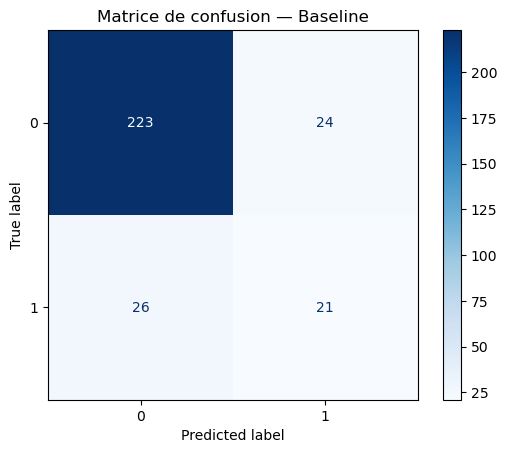

In [43]:
# Probabilité d'attrition sur le jeu test
y_proba_test = Model_pipeline.predict_proba(X_test)[:, 1]

# Application du seuil sélectionné par CV
y_pred_optimized = (y_proba_test >= best_threshold).astype(int)

print("==" * 31)
print("==" * 11, "BASELINE REPORTS", "==" * 11)
print()
print()
print("BASELINE = LogisticRegression")
print("- " * 31)


print(classification_report(y_test, y_pred_optimized))
# roc_auc = roc_auc_score(y_test, y_predict_proba)

# pr_auc = average_precision_score(y_test, y_predict_proba)
print("- " * 31)
print()


# print(f"ROC-AUC : {roc_auc:.3f}")
# print(f"PR-AUC  : {pr_auc:.3f}")

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_optimized, cmap="Blues")
plt.title("Matrice de confusion — Baseline")
plt.show()


In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results_threshold = pd.DataFrame(
    {
        "Seuil": ["Standard (0.50)", f"Optimisé CV ({best_threshold:.3f})"],
        "Precision": [
            precision_score(y_test, y_predict),
            precision_score(y_test, y_pred_optimized),
        ],
        "Recall": [
            recall_score(y_test, y_predict),
            recall_score(y_test, y_pred_optimized),
        ],
        "F1": [f1_score(y_test, y_predict), f1_score(y_test, y_pred_optimized)],
        "Accuracy": [
            accuracy_score(y_test, y_predict),
            accuracy_score(y_test, y_pred_optimized),
        ],
    }
)

results_threshold.round(3)


,Seuil,Precision,Recall,F1,Accuracy
0,Standard (0.50),0.684,0.277,0.394,0.864
1,Optimisé CV (0.320),0.467,0.447,0.457,0.830


### Ajustement du seuil de décision

Au seuil standard de `0,50`, la régression logistique présente une bonne
précision sur la classe d'attrition (0,68), mais un rappel faible (0,28).
Une part importante des départs réels n'est donc pas détectée.

Afin d'obtenir un meilleur compromis entre précision et rappel, le seuil
de décision a été sélectionné uniquement sur les données d'entraînement,
à partir de prédictions out-of-fold obtenues par validation croisée
stratifiée à 5 plis.

Le seuil maximisant le F1-score en validation croisée est de **0,319**.

Appliqué sans modification au jeu de test, ce seuil permet d'obtenir pour
la classe d'attrition :

- précision : **0,478** ;
- rappel : **0,468** ;
- F1-score : **0,473**.

Le rappel progresse ainsi de 0,28 à 0,468 par rapport au seuil standard,
au prix d'une diminution de la précision et de l'accuracy globale.

La ROC-AUC (**0,779**) et la PR-AUC (**0,535**) restent inchangées, puisque
le modèle et ses probabilités prédites ne sont pas modifiés par le choix
du seuil.

Le seuil de 0,319 doit être interprété comme un seuil statistique sélectionné
pour maximiser le F1-score en validation croisée, et non comme un seuil
métier universel. En pratique, le seuil pourrait être ajusté selon le coût
relatif des faux négatifs et des faux positifs dans la politique de rétention.

In [45]:
balanced_model = LogisticRegression(
    class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE
)

balanced_pipeline = Pipeline(
    [("preprocessor",Preprocessor), ("model", balanced_model)]
)

balanced_pipeline.fit(X_train, y_train)

y_proba_balanced = balanced_pipeline.predict_proba(X_test)[:, 1]

y_pred_balanced = balanced_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_balanced, digits=3))

print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_balanced):.3f}")

print(f"PR-AUC  : {average_precision_score(y_test, y_proba_balanced):.3f}")


              precision    recall  f1-score   support

           0      0.930     0.802     0.861       247
           1      0.395     0.681     0.500        47

    accuracy                          0.782       294
   macro avg      0.662     0.741     0.680       294
weighted avg      0.844     0.782     0.803       294

ROC-AUC : 0.783
PR-AUC  : 0.522


### Prise en compte du déséquilibre des classes

La variable cible présente un déséquilibre important, les départs représentant
environ 16 % des collaborateurs.

Une seconde régression logistique utilisant `class_weight="balanced"` a donc
été évaluée afin d'accorder davantage d'importance à la classe minoritaire
pendant l'apprentissage.

Sur le jeu de test, cette spécification obtient un rappel de **0,660** pour
la classe d'attrition, contre **0,280** pour la régression logistique standard
au seuil de 0,50 et **0,468** après ajustement du seuil à 0,319.

Cette amélioration de la détection s'accompagne cependant d'une diminution
de la précision à **0,388**, traduisant une augmentation du nombre de faux
positifs.

Les capacités globales de discrimination restent proches entre les deux
modèles : la ROC-AUC passe de **0,779 à 0,783**, tandis que la PR-AUC passe
de **0,535 à 0,523**.

La pondération des classes ne semble donc pas améliorer fortement le classement
global des individus, mais modifie le compromis entre faux positifs et faux
négatifs en privilégiant la détection des départs.

Dans un contexte de rétention RH, cette propriété peut être pertinente lorsque
le coût associé à un départ non détecté est considéré comme supérieur au coût
d'une intervention préventive auprès d'un collaborateur qui serait finalement
resté.

In [46]:
from sklearn.model_selection import cross_validate

scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision"}

cv_standard = cross_validate(Model_pipeline, X_train, y_train, cv=cv, scoring=scoring)

cv_balanced = cross_validate(
    balanced_pipeline, X_train, y_train, cv=cv, scoring=scoring
)

cv_comparison = pd.DataFrame(
    {
        "Modèle": ["Logistique standard", "Logistique balanced"],
        "ROC-AUC moyenne": [
            cv_standard["test_roc_auc"].mean(),
            cv_balanced["test_roc_auc"].mean(),
        ],
        "ROC-AUC std": [
            cv_standard["test_roc_auc"].std(),
            cv_balanced["test_roc_auc"].std(),
        ],
        "PR-AUC moyenne": [
            cv_standard["test_pr_auc"].mean(),
            cv_balanced["test_pr_auc"].mean(),
        ],
        "PR-AUC std": [
            cv_standard["test_pr_auc"].std(),
            cv_balanced["test_pr_auc"].std(),
        ],
    }
)

cv_comparison.round(3)


,Modèle,ROC-AUC moyenne,ROC-AUC std,PR-AUC moyenne,PR-AUC std
0,Logistique standard,0.819,0.030,0.610,0.067
1,Logistique balanced,0.815,0.027,0.591,0.071


### Sélection du modèle logistique

Les régressions logistiques standard et pondérée ont été comparées par
validation croisée stratifiée à cinq plis.

La régression logistique standard obtient une ROC-AUC moyenne de
**0,820 ± 0,031** et une PR-AUC moyenne de **0,613 ± 0,067**.

La régression pondérée avec `class_weight="balanced"` obtient respectivement
**0,815 ± 0,028** et **0,595 ± 0,069**.

La pondération des classes augmente le rappel de la classe d'attrition pour
un seuil de décision fixé à 0,50, mais n'améliore pas la capacité globale
du modèle à classer les collaborateurs selon leur niveau de risque.

La régression logistique standard est donc retenue comme modèle principal.
Elle présente également l'avantage de fournir des probabilités directement
exploitables pour construire un score de risque.

Le choix du modèle et le choix du seuil de décision sont considérés comme
deux problématiques distinctes. Le modèle produit une probabilité
d'attrition, tandis que le seuil peut être ajusté en fonction du compromis
métier recherché entre détection des départs et nombre de faux positifs.

In [47]:
# Noms des variables après preprocessing
feature_names = (
    Model_pipeline
    .named_steps["Preprocessor"]
    .get_feature_names_out()
)

# Coefficients de la régression
coefficients = (
    Model_pipeline
    .named_steps["Model"]
    .coef_[0]
)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Odds Ratio
coef_df["OddsRatio"] = np.exp(
    coef_df["Coefficient"]
)

coef_df = coef_df.sort_values(
    "OddsRatio",
    ascending=False
)

coef_df.round(3)

,Feature,Coefficient,OddsRatio
11,categorical__OverTime_Yes,1.583,4.868
22,categorical__BusinessTravel_Travel_Frequently,1.427,4.167
19,categorical__JobRole_Sales Representative,1.311,3.711
13,categorical__JobRole_Laboratory Technician,1.192,3.295
12,categorical__JobRole_Human Resources,0.709,2.032
18,categorical__JobRole_Sales Executive,0.702,2.018
23,categorical__BusinessTravel_Travel_Rarely,0.640,1.897
21,categorical__MaritalStatus_Single,0.517,1.677
10,Numeric__DistanceFromHome,0.340,1.405
2,Numeric__YearsAtCompany,0.241,1.272


In [48]:
import statsmodels.api as sm

# Transformation du train avec le preprocessing déjà appris
X_train_processed = Model_pipeline.named_steps["Preprocessor"].transform(X_train)

feature_names = Model_pipeline.named_steps["Preprocessor"].get_feature_names_out()

# DataFrame nécessaire pour statsmodels
X_train_sm = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)

# Constante
X_train_sm = sm.add_constant(X_train_sm)

# Régression logistique
logit_sm = sm.Logit(y_train, X_train_sm)

result_sm = logit_sm.fit()

print(result_sm.summary())


Optimization terminated successfully.
         Current function value: 0.309282
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:          AttritionFlag   No. Observations:                 1176
Model:                          Logit   Df Residuals:                     1146
Method:                           MLE   Df Model:                           29
Date:                Fri, 11 Sep 2026   Pseudo R-squ.:                  0.3007
Time:                        02:32:38   Log-Likelihood:                -363.72
converged:                       True   LL-Null:                       -520.09
Covariance Type:            nonrobust   LLR p-value:                 2.418e-49
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
const                                 

In [49]:
# Coefficients et intervalles de confiance
conf = result_sm.conf_int()

or_table = pd.DataFrame(
    {
        "Feature": result_sm.params.index,
        "Coefficient": result_sm.params.values,
        "P_Value": result_sm.pvalues.values,
        "OR": np.exp(result_sm.params.values),
        "OR_Lower_95": np.exp(conf[0].values),
        "OR_Upper_95": np.exp(conf[1].values),
    }
)

# Retrait de l'intercept
or_table = or_table[or_table["Feature"] != "const"].copy()

or_table["Significant_005"] = or_table["P_Value"] < 0.05

or_table = or_table.sort_values("OR", ascending=False)

or_table.round(3)


,Feature,Coefficient,P_Value,OR,OR_Lower_95,OR_Upper_95,Significant_005
20,categorical__JobRole_Sales Representative,2.231,0.000,9.311,2.756,31.449,True
14,categorical__JobRole_Laboratory Technician,1.978,0.000,7.229,2.498,20.918,True
23,categorical__BusinessTravel_Travel_Frequently,1.856,0.000,6.400,2.645,15.489,True
12,categorical__OverTime_Yes,1.698,0.000,5.461,3.657,8.153,True
19,categorical__JobRole_Sales Executive,1.285,0.012,3.614,1.333,9.799,True
13,categorical__JobRole_Human Resources,1.092,0.169,2.981,0.629,14.134,False
24,categorical__BusinessTravel_Travel_Rarely,1.011,0.016,2.750,1.206,6.269,True
18,categorical__JobRole_Research Scientist,0.702,0.209,2.018,0.675,6.035,False
22,categorical__MaritalStatus_Single,0.573,0.114,1.773,0.871,3.611,False
11,Numeric__DistanceFromHome,0.365,0.000,1.441,1.197,1.734,True


In [53]:
encoder = Preprocessor.named_transformers_["categorical"].named_steps["OneHot"]

references = pd.DataFrame(
    {
        "Variable": categorical_features,
        "Reference": [categories[0] for categories in encoder.categories_],
    }
)

references


,Variable,Reference
0,OverTime,No
1,JobRole,Healthcare Representative
2,MaritalStatus,Divorced
3,BusinessTravel,Non-Travel
4,EducationField,Human Resources


In [54]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_proba_test)

print(f"Brier Score : {brier:.4f}")


Brier Score : 0.1048


In [55]:
prevalence_train = y_train.mean()

y_proba_naive = np.full(len(y_test), prevalence_train)

brier_naive = brier_score_loss(y_test, y_proba_naive)

print(f"Prévalence train : {prevalence_train:.3f}")
print(f"Brier modèle     : {brier:.4f}")
print(f"Brier naïf       : {brier_naive:.4f}")


Prévalence train : 0.162
Brier modèle     : 0.1048
Brier naïf       : 0.1343


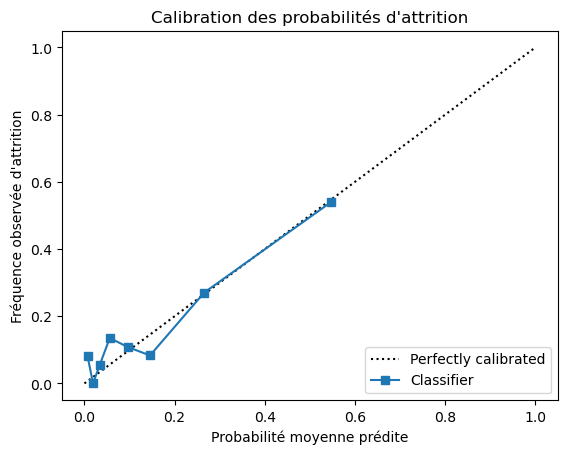

In [56]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(y_test, y_proba_test, n_bins=8, strategy="quantile")

plt.title("Calibration des probabilités d'attrition")
plt.xlabel("Probabilité moyenne prédite")
plt.ylabel("Fréquence observée d'attrition")
plt.show()


In [57]:
score_analysis = pd.DataFrame({"Attrition": y_test.values, "Probability": y_proba_test})

score_analysis.groupby("Attrition")["Probability"].describe().round(3)


,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
0,247.0,0.109,0.129,0.001,0.022,0.057,0.142,0.684
1,47.0,0.344,0.278,0.006,0.087,0.308,0.551,0.970


### Calibration et distribution des probabilités

Le modèle obtient un Brier Score de **0,1048**, contre **0,1343**
pour un modèle naïf attribuant à chaque collaborateur la prévalence
observée sur l'échantillon d'entraînement (16,2 %).

Cela représente une réduction d'environ **22 % de l'erreur probabiliste**
par rapport à cette référence naïve.

La courbe de calibration montre une concordance globalement satisfaisante
entre les probabilités prédites et les fréquences d'attrition observées.
Des fluctuations apparaissent néanmoins dans les zones de faible
probabilité, ce qui doit être interprété avec prudence compte tenu du
nombre limité de départs dans le jeu de test (47 observations).

Les collaborateurs restés présentent une probabilité médiane prédite
de **5,7 %**, contre **30,8 %** pour les collaborateurs ayant quitté
l'entreprise. Les probabilités moyennes sont respectivement de
**10,9 %** et **34,4 %**.

Le modèle parvient donc à attribuer des scores de risque sensiblement
plus élevés aux départs réels, tout en conservant un chevauchement
entre les deux populations. Les probabilités doivent ainsi être
interprétées comme des scores de risque probabilistes et non comme
des prédictions certaines de départ.

In [58]:
# Probabilité d'attrition pour l'ensemble des collaborateurs
X_all = df_model[selected_features].copy()

df_scoring = df_model[
    ["EmployeeNumber", "Attrition", "AttritionFlag"]
].copy()

df_scoring["AttritionProbability"] = (
    Model_pipeline.predict_proba(X_all)[:, 1]
)

df_scoring["AttritionProbabilityPct"] = (
    df_scoring["AttritionProbability"] * 100
).round(2)

df_scoring.head()

,EmployeeNumber,Attrition,AttritionFlag,AttritionProbability,AttritionProbabilityPct
0,1,Yes,1,0.247446,24.74
1,2,No,0,0.046318,4.63
2,4,Yes,1,0.380995,38.10
3,5,No,0,0.194078,19.41
4,7,No,0,0.185281,18.53


In [59]:
df_scoring["AttritionProbability"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.80, 0.90, 0.95]
).round(3)


count    1470.000
mean        0.159
std         0.190
min         0.001
10%         0.012
25%         0.029
50%         0.082
75%         0.207
80%         0.263
90%         0.427
95%         0.608
max         0.970
Name: AttritionProbability, dtype: float64

In [60]:
df_scoring.groupby("Attrition")["AttritionProbability"].describe().round(3)


,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,0.112,0.125,0.001,0.024,0.066,0.153,0.753
Yes,237.0,0.402,0.267,0.006,0.175,0.393,0.627,0.970


In [61]:
q50 = df_scoring["AttritionProbability"].quantile(0.50)
q75 = df_scoring["AttritionProbability"].quantile(0.75)
q90 = df_scoring["AttritionProbability"].quantile(0.90)

df_scoring["RiskLevel"] = pd.cut(
    df_scoring["AttritionProbability"],
    bins=[-np.inf, q50, q75, q90, np.inf],
    labels=["Faible", "Modéré", "Élevé", "Critique"],
)


In [62]:
risk_summary = (
    df_scoring.groupby("RiskLevel", observed=True)
    .agg(
        EmployeeCount=("EmployeeNumber", "count"),
        EmployeesLeft=("AttritionFlag", "sum"),
        AverageProbability=("AttritionProbability", "mean"),
    )
    .reset_index()
)

risk_summary["AttritionRate"] = (
    risk_summary["EmployeesLeft"] / risk_summary["EmployeeCount"]
)

risk_summary[["AverageProbability", "AttritionRate"]] *= 100

risk_summary.round(2)


,RiskLevel,EmployeeCount,EmployeesLeft,AverageProbability,AttritionRate
0,Faible,735,39,3.31,5.31
1,Modéré,367,31,13.71,8.45
2,Élevé,221,63,30.16,28.51
3,Critique,147,104,62.46,70.75


In [63]:
# Ordre des niveaux de risque
risk_order = {"Faible": 1, "Modéré": 2, "Élevé": 3, "Critique": 4}

df_scoring["RiskLevelOrder"] = df_scoring["RiskLevel"].astype(str).map(risk_order)

# Indicateur basé sur le seuil sélectionné par CV
df_scoring["PredictedAttrition"] = (
    df_scoring["AttritionProbability"] >= best_threshold
).astype(int)

from pathlib import Path

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

scoring_export = df_scoring[
    [
        "EmployeeNumber",
        "Attrition",
        "AttritionFlag",
        "AttritionProbability",
        "AttritionProbabilityPct",
        "RiskLevel",
        "RiskLevelOrder",
        "PredictedAttrition",
    ]
].copy()

scoring_export.to_csv(OUTPUT_DIR / "employee_scoring.csv", index=False)

print(scoring_export.shape)
scoring_export.head()


(1470, 8)


,EmployeeNumber,Attrition,AttritionFlag,AttritionProbability,AttritionProbabilityPct,RiskLevel,RiskLevelOrder,PredictedAttrition
0,1,Yes,1,0.247446,24.74,Élevé,3,0
1,2,No,0,0.046318,4.63,Faible,1,0
2,4,Yes,1,0.380995,38.10,Élevé,3,1
3,5,No,0,0.194078,19.41,Modéré,2,0
4,7,No,0,0.185281,18.53,Modéré,2,0


In [64]:
import joblib

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(Model_pipeline, MODEL_DIR / "attrition_pipeline.joblib")

print("Pipeline sauvegardé.")


Pipeline sauvegardé.


In [65]:
or_export = or_table.copy()

or_export.to_csv(OUTPUT_DIR / "model_factors.csv", index=False)


## Conclusion

Une régression logistique a été développée afin d'estimer le risque
d'attrition des collaborateurs.

Le modèle standard a été retenu après comparaison avec une régression
pondérée. Il obtient une ROC-AUC de **0,779** et une PR-AUC de **0,535**
sur le jeu de test. En validation croisée, les performances moyennes
atteignent respectivement **0,820 ± 0,031** et **0,613 ± 0,067**.

Un seuil de décision de **0,319** a été sélectionné sur les données
d'entraînement par validation croisée afin de maximiser le F1-score.
Sur le jeu de test, ce seuil conduit à une précision de **47,8 %**,
un rappel de **46,8 %** et un F1-score de **47,3 %** pour la classe
d'attrition.

Le modèle présente également une calibration globalement satisfaisante,
avec un Brier Score de **0,1048**, contre **0,1343** pour une référence
naïve fondée sur la prévalence.

L'analyse multivariée met notamment en évidence des associations
ajustées avec les heures supplémentaires, les déplacements
professionnels, certains métiers, la distance domicile-travail,
l'âge, les stock-options, l'implication et plusieurs dimensions
de satisfaction.

Enfin, les scores ont été regroupés en quatre niveaux relatifs de risque.
Les **25 % de collaborateurs présentant les scores les plus élevés
concentrent environ 70,5 % des départs observés**, tandis que le groupe
Critique, représentant 10 % de l'effectif, concentre environ 43,9 %
des départs.

Ces résultats doivent être interprétés comme des associations et des
estimations de risque, et non comme des relations causales. Les
performances hors échantillon sont évaluées séparément sur le jeu
de test et par validation croisée.

In [66]:
df_model.to_csv(OUTPUT_DIR / "df_model.csv", index=False)